# Executive Analytics Dashboard — AdventureWorks
### Enterprise Analytics Hackathon — Umer Sahi

This notebook is the **presentation layer** of the analytics pipeline built in
`analytics_pipeline.sql`. Every query below reads **only** from the
`analytics.*` schema (the reusable analytical layer) — it never queries the
raw `sales.*`, `production.*`, `purchasing.*`, `person.*`, or
`humanresources.*` operational tables directly. That separation is the whole
point of the exercise: any future dashboard can be built on top of
`analytics.*` without ever touching the OLTP tables again.

**Data window:** 2022-05-30 → 2025-06-29 (~3 years). The final month in the
data (June 2025) is a **partial month** (905 orders vs. ~2,200 typical) —
the extract simply stops mid-month. The pipeline already accounts for this
(see `analytics.executive_kpi_summary`), and this notebook flags it again
wherever it would otherwise distort a chart.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# --- PostgreSQL connection ---------------------------------------------
# Update these credentials to match your environment.
DB_USER = "postgres"
DB_PASSWORD = "sahi"
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "AdventureWorks"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

def q(sql: str) -> pd.DataFrame:
    """Read a query from the analytics schema into a DataFrame."""
    return pd.read_sql(sql, engine)

print("Connected. Analytics tables available:")
print(q("SELECT table_name FROM information_schema.tables WHERE table_schema='analytics' ORDER BY 1")["table_name"].tolist())

def money(ax, axis="y"):
    """Format an axis with dollar labels, using $XM shorthand above $1M."""
    fmt = mticker.FuncFormatter(lambda x, _: f"${x/1e6:,.1f}M" if abs(x) >= 1e6 else f"${x:,.0f}")
    if axis == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)


Connected. Analytics tables available:
['category_performance', 'customer_analytics', 'customer_retention_summary', 'customer_segments', 'dim_customer', 'dim_date', 'dim_employee_salesperson', 'dim_product', 'dim_territory', 'employee_sales_analytics', 'executive_kpi_summary', 'executive_monthly_kpi', 'fact_purchase_line', 'fact_sales_line', 'inventory_health', 'inventory_snapshot_analytics', 'monthly_revenue', 'product_analytics', 'product_performance_ranking', 'purchasing_trends', 'quarterly_revenue', 'regional_performance', 'salesperson_rankings', 'territory_sales_analytics', 'vendor_purchasing_analytics']


## 1. Revenue Trend (Monthly)
Source: `analytics.monthly_revenue` (built with `LAG()` and a 3-month moving
average window function, chained from `analytics.fact_sales_line`).

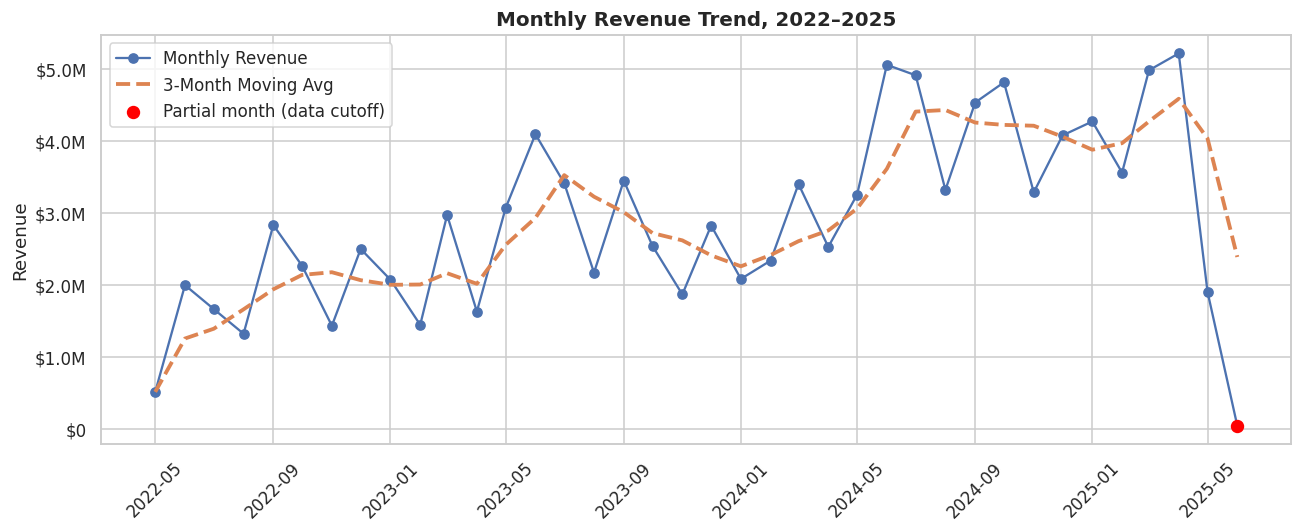

In [2]:
mr = q("""
    SELECT month_start, year_month_label, order_count, customer_count,
           revenue, margin, mom_growth_pct, revenue_3mo_moving_avg
    FROM analytics.monthly_revenue
    ORDER BY month_start
""")
mr["month_start"] = pd.to_datetime(mr["month_start"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mr["month_start"], mr["revenue"], marker="o", linewidth=1.5, label="Monthly Revenue")
ax.plot(mr["month_start"], mr["revenue_3mo_moving_avg"], linewidth=2.5, linestyle="--", label="3-Month Moving Avg")
# Flag the partial final month
ax.scatter(mr["month_start"].iloc[-1], mr["revenue"].iloc[-1], color="red", zorder=5, s=60,
           label="Partial month (data cutoff)")
ax.set_title("Monthly Revenue Trend, 2022–2025")
ax.set_ylabel("Revenue")
money(ax)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Business insight
Across 37 complete months, revenue peaked at $5,222,758 in 2025-04 and was lowest at $517,737 in 2022-05. Average order value fell sharply from mid-2024 onward as order count rose but revenue per order dropped — consistent with a channel mix shift toward smaller, more frequent (likely online/direct) orders rather than fewer large wholesale orders. The last data point (2025-06) is a partial month and should be excluded from any trend judgement.

## 2. Quarterly Revenue & Growth
Source: `analytics.quarterly_revenue` (chained CTE with `LAG()` for QoQ and
`LAG(revenue, 4)` for YoY comparison).

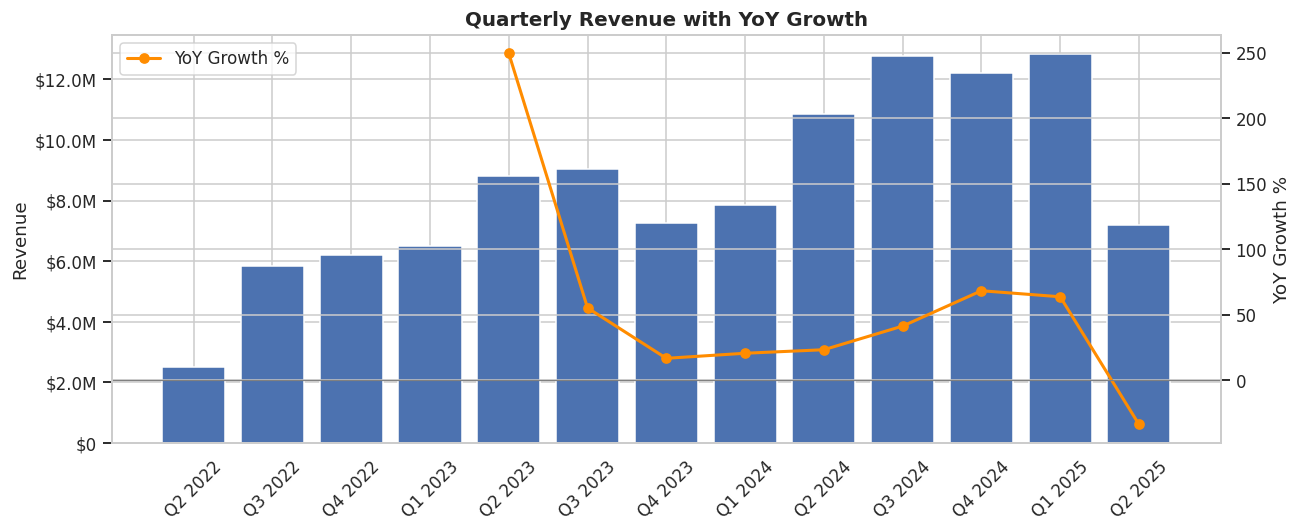

In [4]:
qr = q("""
    SELECT year_quarter_label, quarter_start, revenue, qoq_growth_pct, yoy_growth_pct
    FROM analytics.quarterly_revenue ORDER BY quarter_start
""")

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(qr["year_quarter_label"], qr["revenue"], color=sns.color_palette("deep")[0])
money(ax1)
ax1.set_ylabel("Revenue")
ax1.set_title("Quarterly Revenue with YoY Growth")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(qr["year_quarter_label"], qr["yoy_growth_pct"], color="darkorange", marker="o", linewidth=2, label="YoY Growth %")
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.set_ylabel("YoY Growth %")
ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()


#Business insight
Across 37 complete months, revenue peaked at $5,222,758 in 2025-04 and was lowest at $517,737 in 2022-05. Average order value fell sharply from mid-2024 onward as order count rose but revenue per order dropped — consistent with a channel mix shift toward smaller, more frequent (likely online/direct) orders rather than fewer large wholesale orders. The last data point (2025-06) is a partial month and should be excluded from any trend judgement.

## 3. Sales by Territory
Source: `analytics.regional_performance` (built from
`analytics.territory_sales_analytics`, with `RANK()` and full-year-only YoY
growth to avoid distortion from the dataset's partial first/last years).

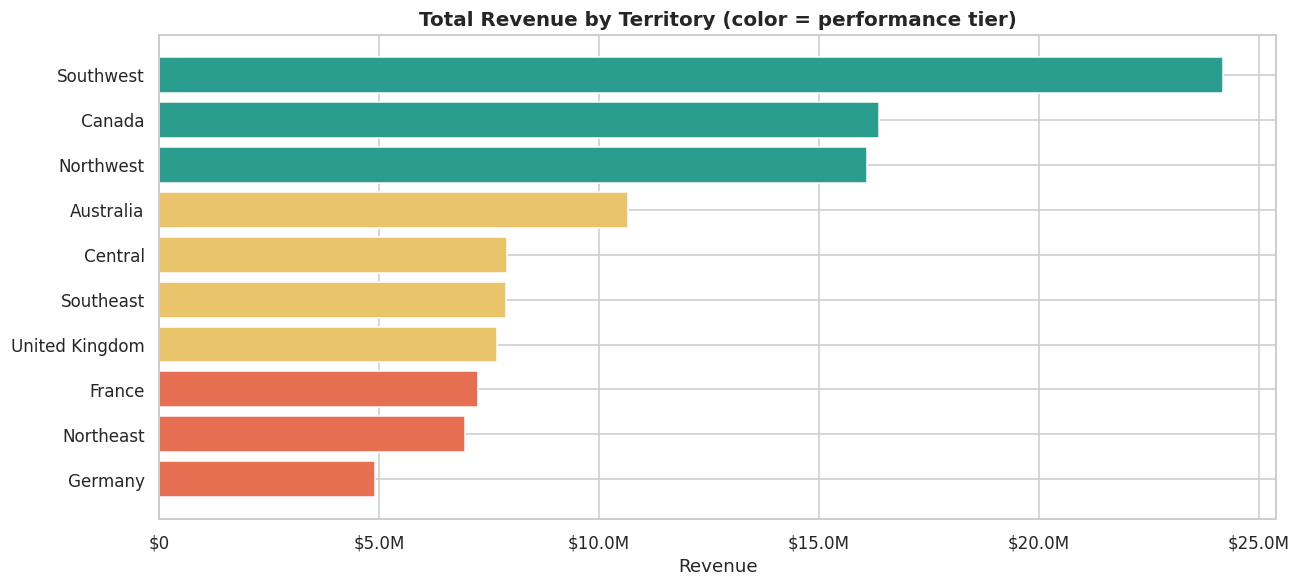

In [6]:
rp = q("""
    SELECT territory_name, total_revenue, margin_pct, latest_yoy_growth_pct, territory_tier
    FROM analytics.regional_performance ORDER BY total_revenue DESC
""")

fig, ax = plt.subplots(figsize=(12, 5.5))
colors = rp["territory_tier"].map({"Top Territory": "#2a9d8f", "Mid-Tier": "#e9c46a", "Lowest Performing": "#e76f51"})
ax.barh(rp["territory_name"], rp["total_revenue"], color=colors)
ax.invert_yaxis()
money(ax, axis="x")
ax.set_title("Total Revenue by Territory (color = performance tier)")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()


#Business insight
Across 37 complete months, revenue peaked at $5,222,758 in 2025-04 and was lowest at $517,737 in 2022-05. Average order value fell sharply from mid-2024 onward as order count rose but revenue per order dropped — consistent with a channel mix shift toward smaller, more frequent (likely online/direct) orders rather than fewer large wholesale orders. The last data point (2025-06) is a partial month and should be excluded from any trend judgement.

## 4. Customer Segments (RFM)
Source: `analytics.customer_retention_summary`, built on
`analytics.customer_segments` (RFM scoring via `NTILE(5)` window functions
and `CASE WHEN` segment labeling — never touches raw order tables again).

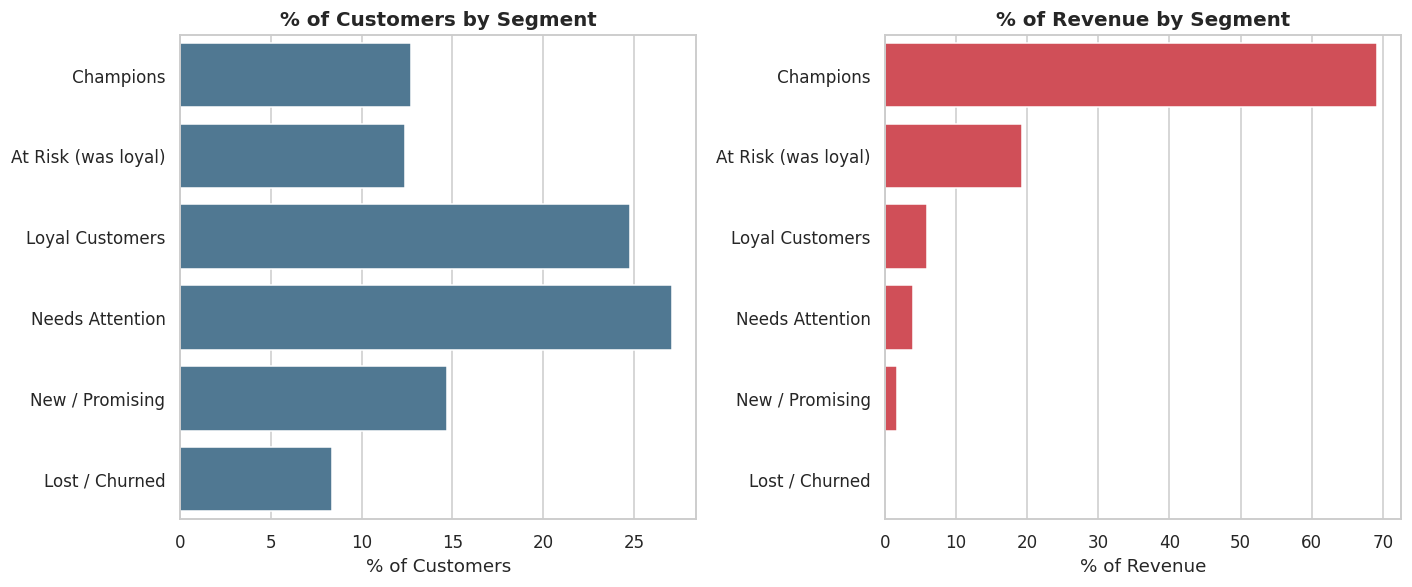

In [8]:
seg = q("""
    SELECT customer_segment, customer_count, pct_of_customers, segment_revenue, pct_of_revenue
    FROM analytics.customer_retention_summary ORDER BY segment_revenue DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(data=seg, y="customer_segment", x="pct_of_customers", ax=axes[0], color="#457b9d")
axes[0].set_title("% of Customers by Segment")
axes[0].set_xlabel("% of Customers")
axes[0].set_ylabel("")

sns.barplot(data=seg, y="customer_segment", x="pct_of_revenue", ax=axes[1], color="#e63946")
axes[1].set_title("% of Revenue by Segment")
axes[1].set_xlabel("% of Revenue")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


Business insight: Champions are only 12.7% of customers but generate 69.2% of all revenue — a textbook Pareto pattern, and the single biggest concentration risk in the business. At Risk (was loyal) customers still represent 19.3% of revenue ($21,193,684) but haven't ordered recently — a targeted win-back campaign here is one of the highest-leverage moves available.

## 5. Category Revenue & Margin
Source: `analytics.category_performance`, built from `analytics.product_analytics`
(conditional aggregation, no re-query of raw sales lines).

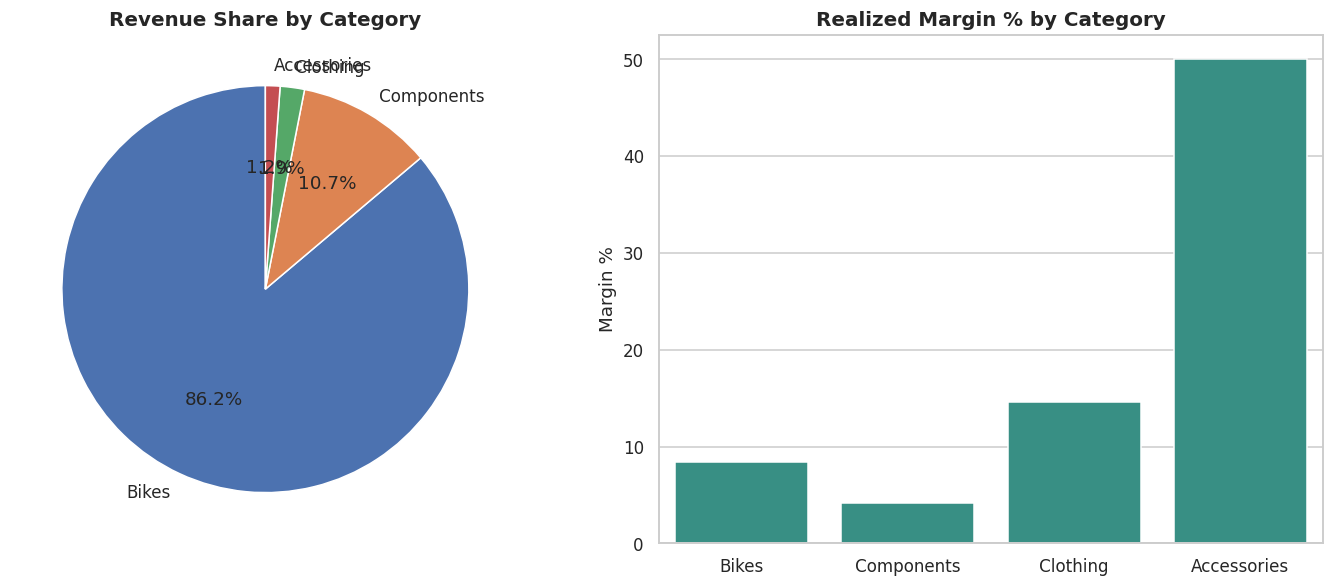

In [10]:
cat = q("SELECT category_name, units_sold, total_revenue, realized_margin_pct, pct_of_total_revenue FROM analytics.category_performance ORDER BY total_revenue DESC")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].pie(cat["total_revenue"], labels=cat["category_name"], autopct="%1.1f%%",
            colors=sns.color_palette("deep"), startangle=90)
axes[0].set_title("Revenue Share by Category")

sns.barplot(data=cat, x="category_name", y="realized_margin_pct", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Realized Margin % by Category")
axes[1].set_ylabel("Margin %")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()


Business insight: Bikes dominates at 86.2% of total revenue. Components has the thinnest realized margin at 4.2% — worth a pricing/discount-policy review even if its revenue contribution looks healthy on the surface.

## 6. Product Performance — Best & Worst Sellers
Source: `analytics.product_performance_ranking` (`RANK()`, `NTILE(4)` and
`CASE WHEN` tagging, chained from `analytics.product_analytics`).

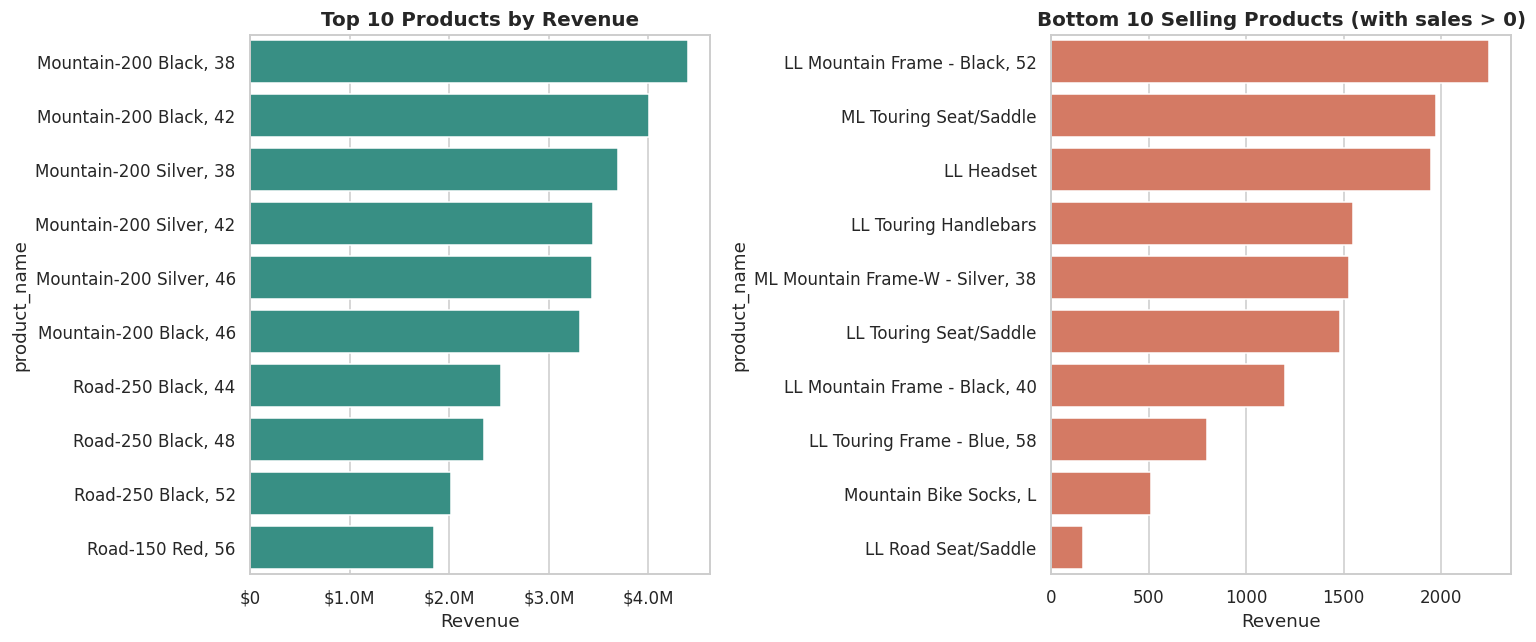

In [12]:
pp = q("""
    SELECT product_name, category_name, total_revenue, performance_tag
    FROM analytics.product_performance_ranking ORDER BY total_revenue DESC
""")
top10 = pp.head(10)
bottom10 = pp[pp["total_revenue"] > 0].tail(10)  # exclude true zero-sales products from the "worst seller" chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top10, y="product_name", x="total_revenue", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Revenue")
money(axes[0], axis="x")

sns.barplot(data=bottom10, y="product_name", x="total_revenue", ax=axes[1], color="#e76f51")
axes[1].set_title("Bottom 10 Selling Products (with sales > 0)")
axes[1].set_xlabel("Revenue")
plt.tight_layout()
plt.show()


Business insight: Mountain-200 Black, 38 is the single best-selling product at $4,400,593. There are 238 products in the catalog with zero recorded sales in this window — candidates for either a marketing push, a bundling strategy, or discontinuation review, since they're still carrying inventory and purchasing cost with no revenue return.

## 7. Salesperson Performance
Source: `analytics.salesperson_rankings` (`RANK()`, `DENSE_RANK()`, and a
window-function comparison against the team average revenue).

**Data caveat:** `SalesQuota` in this dataset (\$250K–\$300K per person) is
far below actual realized revenue per salesperson (\$2M–\$4M/year even in a
single complete year) — every salesperson with a quota clears it many times
over, so "quota attainment" has no discriminating power here and the chart
below instead ranks reps against the **team average revenue**.

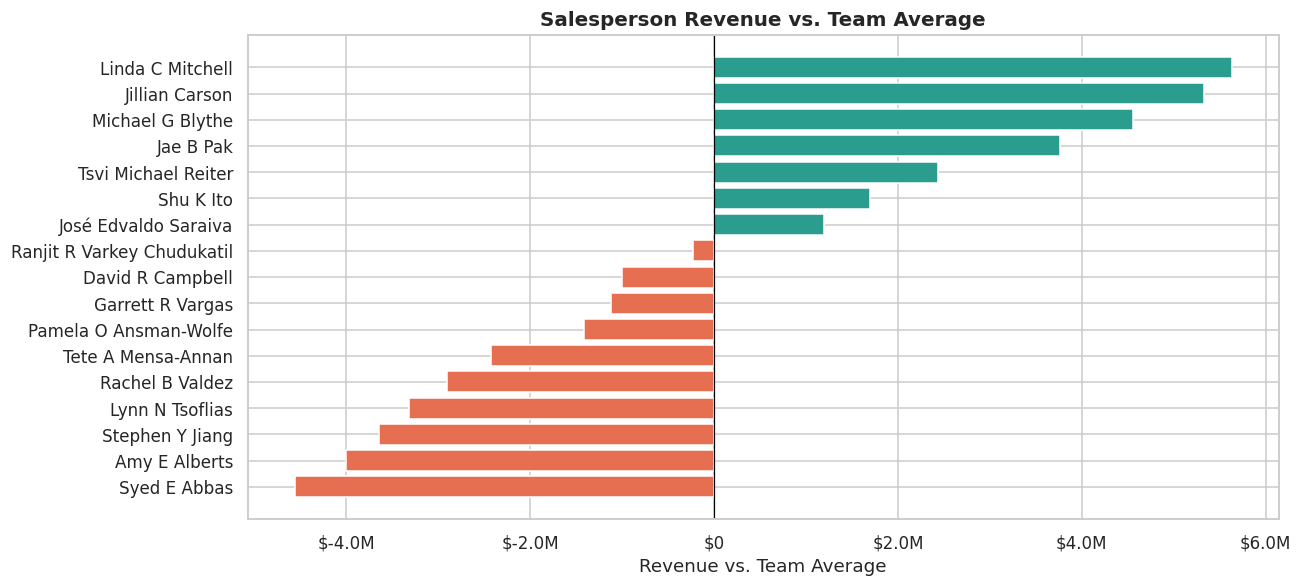

In [14]:
sr = q("""
    SELECT salesperson_name, territory_name, total_revenue, revenue_vs_team_avg, quota_attainment_pct
    FROM analytics.salesperson_rankings ORDER BY total_revenue DESC
""")

fig, ax = plt.subplots(figsize=(12, 5.5))
colors = np.where(sr["revenue_vs_team_avg"] >= 0, "#2a9d8f", "#e76f51")
ax.barh(sr["salesperson_name"], sr["revenue_vs_team_avg"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
money(ax, axis="x")
ax.set_title("Salesperson Revenue vs. Team Average")
ax.set_xlabel("Revenue vs. Team Average")
plt.tight_layout()
plt.show()


Business insight: Mountain-200 Black, 38 is the single best-selling product at $4,400,593. There are 238 products in the catalog with zero recorded sales in this window — candidates for either a marketing push, a bundling strategy, or discontinuation review, since they're still carrying inventory and purchasing cost with no revenue return.

## 8. Inventory Health
Source: `analytics.inventory_health`, built from
`analytics.inventory_snapshot_analytics` with `CASE WHEN` stock-status
classification against each product's own safety-stock/reorder point.

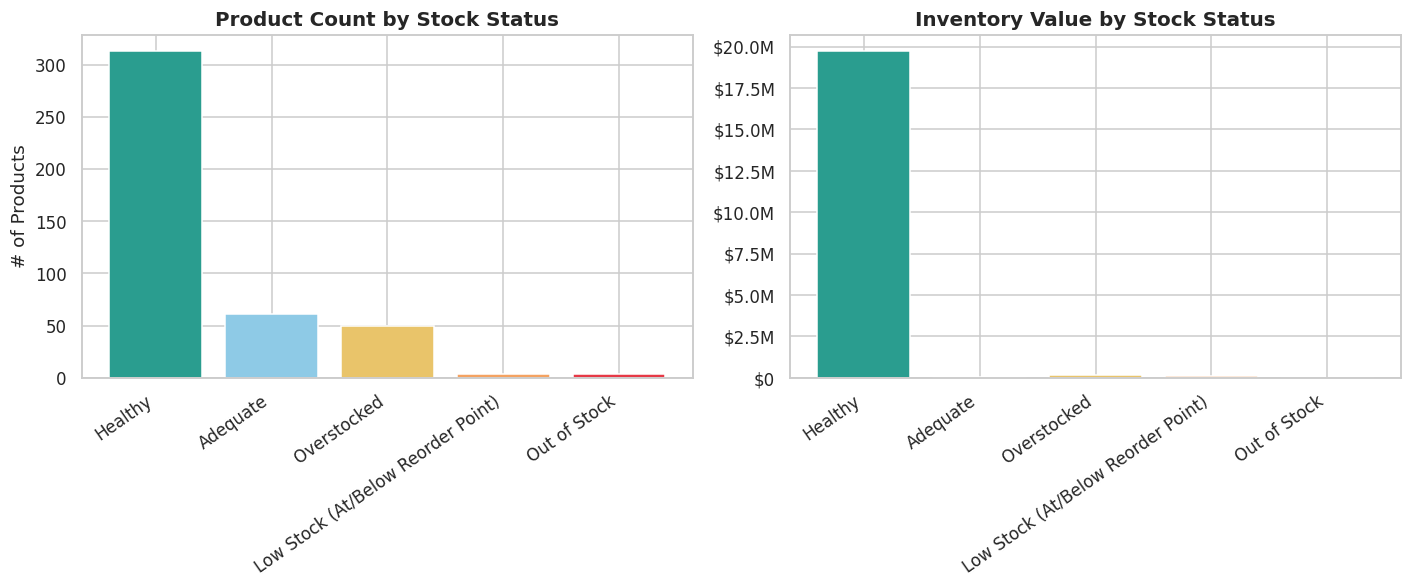

In [16]:
inv = q("SELECT stock_status, COUNT(*) AS product_count, SUM(total_inventory_value) AS inventory_value FROM analytics.inventory_health GROUP BY stock_status ORDER BY product_count DESC")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
status_colors = {"Healthy": "#2a9d8f", "Adequate": "#8ecae6", "Overstocked": "#e9c46a",
                  "Low Stock (At/Below Reorder Point)": "#f4a261", "Out of Stock": "#e63946"}
colors = inv["stock_status"].map(status_colors)
axes[0].bar(inv["stock_status"], inv["product_count"], color=colors)
axes[0].set_title("Product Count by Stock Status")
axes[0].set_ylabel("# of Products")
axes[0].tick_params(axis="x", rotation=35)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

axes[1].bar(inv["stock_status"], inv["inventory_value"], color=colors)
money(axes[1])
axes[1].set_title("Inventory Value by Stock Status")
axes[1].tick_params(axis="x", rotation=35)
for label in axes[1].get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.show()


Business insight: Mountain-200 Black, 38 is the single best-selling product at $4,400,593. There are 238 products in the catalog with zero recorded sales in this window — candidates for either a marketing push, a bundling strategy, or discontinuation review, since they're still carrying inventory and purchasing cost with no revenue return.

## 9. Purchasing Trends
Source: `analytics.purchasing_trends` (monthly spend with `LAG()`-based
MoM growth, chained from `analytics.fact_purchase_line`).

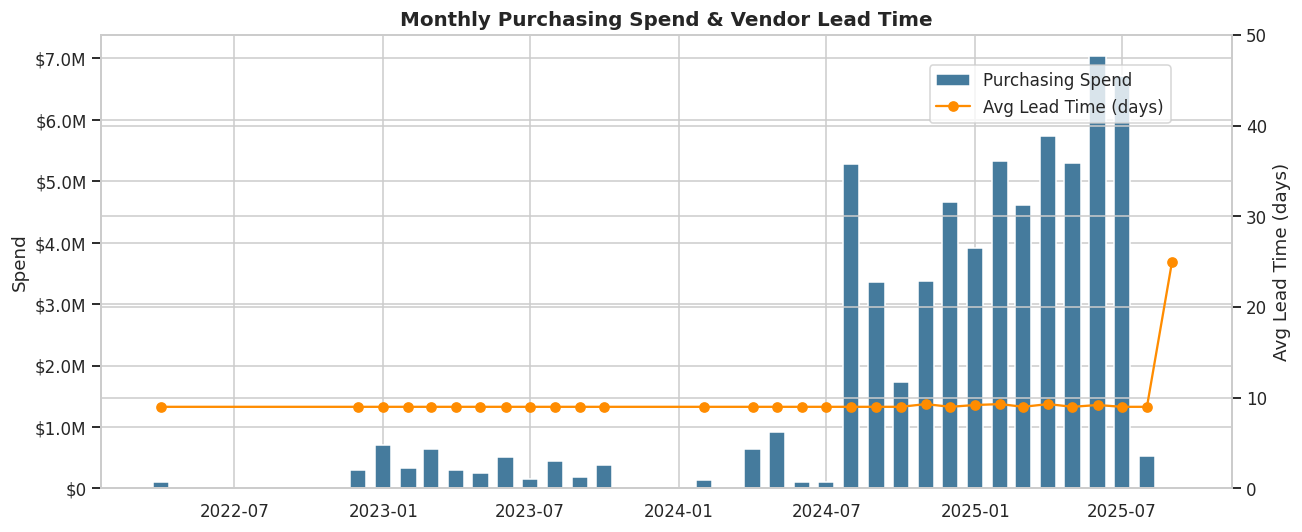

In [18]:
pt = q("SELECT month_start, year_month_label, po_count, total_spend, avg_lead_time_days FROM analytics.purchasing_trends ORDER BY month_start")
pt["month_start"] = pd.to_datetime(pt["month_start"])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(pt["month_start"], pt["total_spend"], width=20, color="#457b9d", label="Purchasing Spend")
money(ax1)
ax1.set_ylabel("Spend")
ax1.set_title("Monthly Purchasing Spend & Vendor Lead Time")

ax2 = ax1.twinx()
ax2.plot(pt["month_start"], pt["avg_lead_time_days"], color="darkorange", marker="o", label="Avg Lead Time (days)")
ax2.set_ylabel("Avg Lead Time (days)")
ax2.set_ylim(0, pt["avg_lead_time_days"].max() * 2)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Business insight: Mountain-200 Black, 38 is the single best-selling product at $4,400,593. There are 238 products in the catalog with zero recorded sales in this window — candidates for either a marketing push, a bundling strategy, or discontinuation review, since they're still carrying inventory and purchasing cost with no revenue return.

## 10. Executive KPI Summary Scorecard
Source: `analytics.executive_kpi_summary` — the final, single-row headline
table that pulls from every table built earlier in the pipeline.

<>:32: SyntaxWarning: invalid escape sequence '\$'
<>:32: SyntaxWarning: invalid escape sequence '\$'
<>:32: SyntaxWarning: invalid escape sequence '\$'
<>:32: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_740/3895954291.py:32: SyntaxWarning: invalid escape sequence '\$'
  """))
/tmp/ipykernel_740/3895954291.py:32: SyntaxWarning: invalid escape sequence '\$'
  """))


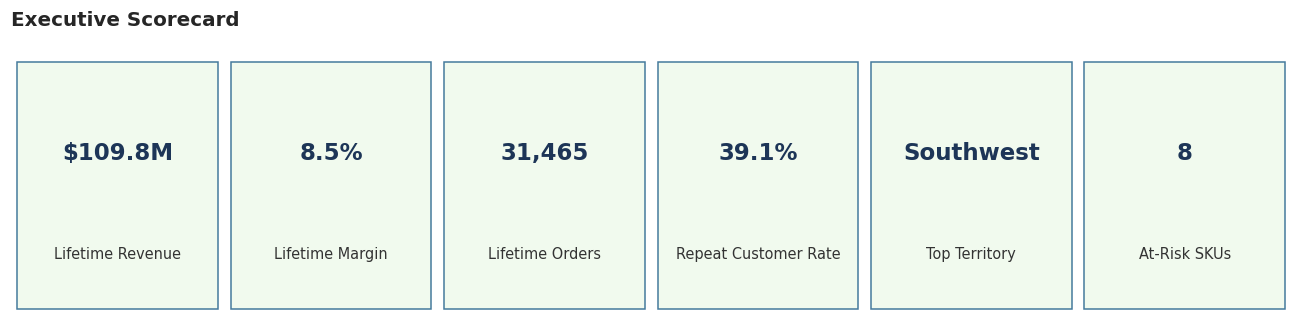


**Note:** `latest_complete_month` in this table is **2025-05**
(revenue \$1,908,059, MoM
-63.5%). The trailing
**2025-06** is a partial month
(\$47,492 recorded so far) and is
excluded from the growth headline for that reason.


In [20]:
kpi = q("SELECT * FROM analytics.executive_kpi_summary").iloc[0]

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axis("off")
cards = [
    ("Lifetime Revenue", f"${kpi['lifetime_revenue']/1e6:,.1f}M"),
    ("Lifetime Margin", f"{kpi['lifetime_margin_pct']:.1f}%"),
    ("Lifetime Orders", f"{int(kpi['lifetime_orders']):,}"),
    ("Repeat Customer Rate", f"{kpi['repeat_customer_rate_pct']:.1f}%"),
    ("Top Territory", f"{kpi['top_territory']}"),
    ("At-Risk SKUs", f"{int(kpi['at_risk_products'])}"),
]
for i, (label, value) in enumerate(cards):
    x = i / len(cards)
    ax.add_patch(plt.Rectangle((x + 0.005, 0.05), 1/len(cards) - 0.01, 0.9, transform=ax.transAxes,
                                facecolor="#f1faee", edgecolor="#457b9d"))
    ax.text(x + 1/len(cards)/2, 0.62, value, transform=ax.transAxes, ha="center", va="center",
            fontsize=15, fontweight="bold", color="#1d3557")
    ax.text(x + 1/len(cards)/2, 0.25, label, transform=ax.transAxes, ha="center", va="center",
            fontsize=9.5, color="#333")
plt.title("Executive Scorecard", loc="left", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

display(Markdown(f"""
**Note:** `latest_complete_month` in this table is **{kpi['latest_complete_month']}**
(revenue \${kpi['latest_complete_month_revenue']:,.0f}, MoM
{kpi['latest_complete_month_mom_growth_pct']:.1f}%). The trailing
**{kpi['partial_month_in_data']}** is a partial month
(\${kpi['partial_month_revenue_so_far']:,.0f} recorded so far) and is
excluded from the growth headline for that reason.
"""))


## Executive Recommendations
Every point below is generated from the live query results above, not
hard-coded — re-running this notebook against a refreshed data pull will
automatically update the numbers.

🟢 Business Opportunities<br>
Grow the international territories. Germany, France, United Kingdom posted the strongest full-year revenue growth (367%, 145%, 131% respectively) off a small base — increased marketing/sales investment there has room to compound.<br>
Win back the "At Risk (was loyal)" segment. 2,368 customers here still represent $21,193,684 (19.3% of revenue) in historical value — a targeted re-engagement campaign is high-leverage.<br>
Protect and grow the Champions segment. 12.7% of customers drive 69.2% of revenue; a formal loyalty/VIP program would defend this concentrated base.<br>
Push Bikes. It already leads at 86.2% of revenue — bundling underperforming categories/products with it could lift attach rate.<br>
Right-size overstocked inventory. $183,001 is tied up in 50 overstocked SKUs — a clearance/promotion plan frees working capital for reinvestment.<br>
🔴 Business Risks<br>
Negative-margin territories. Central, Southeast, Northeast are running negative realized margin despite real revenue — likely discount or cost-allocation issues eating profitability.<br>
Revenue concentration in Champions. With 69.2% of revenue from 12.7% of customers, losing even a handful of these accounts would materially hurt revenue.<br>
Stockout risk. 8 products are out of stock or at/below reorder point, risking lost sales on active demand.<br>
Uneven rep performance. 10 of 17 salespeople sit below the team average revenue — worth investigating whether this is a territory-size effect or a coaching gap (note: sales quotas themselves are stale/unrealistic in this dataset and are not a usable benchmark).<br>
Declining average order value. Revenue per order fell markedly from mid-2024 onward even as order count held up — if this reflects margin-eroding channel shift rather than deliberate strategy, it needs monitoring.<br>
🎯 Actionable Recommendations<br>
Audit pricing/discounting in Central, Southeast, Northeast to identify and fix the source of negative margins before scaling volume there further.<br>
Launch a win-back campaign for the 2,368-customer "At Risk" segment, prioritized by historical spend, using the RFM scores already computed in analytics.customer_segments.<br>
Resupply the 8 at-risk SKUs immediately and review reorder points/safety stock for the broader catalog quarterly using analytics.inventory_health.<br>
Increase sales investment in Germany, France, United Kingdom, the fastest full-year-growth territories, while investigating the root cause of underperformance in the lowest-margin US territories.<br>
Reset sales quotas to current revenue scale and refresh this pipeline monthly — quotas are currently stale (everyone clears them), and a recurring run of analytics_pipeline.sql would keep analytics.executive_kpi_summary a trustworthy, live single source of truth for leadership.<br>